#Exploring Campaign Expenditures and Election Outcomes in North Carolina

This notebook presents an analysis of campaign expenditures and congressional race results in North Carolina. The data used in this study is sourced from the Federal Election Commission ([FEC](https://www.fec.gov/data/elections/house/NC/02/2018/)) and the North Carolina State Board of Elections ([NCSBE](https://cf.ncsbe.gov/CFTxnLkup/)). Our goal is to understand the impact of campaign spending on election outcomes and provide insights that could guide future campaign strategies.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np #Numpy
import pandas as pd #Pandas
import matplotlib.pyplot as plt #Plotly
import seaborn as sns #Seaborn

## Initial Data Exploration


In [ ]:
# Load the datasets
holding = pd.read_csv('/content/drive/MyDrive/Dataset/George Holding for Congress.csv')
matemu = pd.read_csv('/content/drive/MyDrive/Dataset/Japheth Matemu for Congress.csv')
coleman = pd.read_csv('/content/drive/MyDrive/Dataset/Linda Coleman for Congress.csv')
election_results = pd.read_csv('/content/drive/MyDrive/Dataset/election_results.csv')
fec_data = pd.read_csv('/content/drive/MyDrive/Dataset/fec_data.csv')

In [ ]:
# Check the shape of each dataset
print("Holding dataset shape:", holding.shape)
print("Matemu dataset shape:", matemu.shape)
print("Coleman dataset shape:", coleman.shape)

# Examine the first few rows of each dataset
print("\nHolding dataset head:")
print(holding.head())
print("\nMatemu dataset head:")
print(matemu.head())
print("\nColeman dataset head:")
print(coleman.head())

# Get summary statistics for each dataset
print("\nHolding dataset summary:")
print(holding.describe())
print("\nMatemu dataset summary:")
print(matemu.describe())
print("\nColeman dataset summary:")
print(coleman.describe())

# Check for missing values in each dataset
print("\nMissing values in Holding dataset:")
print(holding.isnull().sum())
print("\nMissing values in Matemu dataset:")
print(matemu.isnull().sum())
print("\nMissing values in Coleman dataset:")
print(coleman.isnull().sum())

Holding dataset shape: (2266, 79)
Matemu dataset shape: (26, 79)
Coleman dataset shape: (3388, 79)

Holding dataset head:
  committee_id                    committee_name  report_year report_type  \
0    C00499236  GEORGE HOLDING FOR CONGRESS INC.         2018         30G   
1    C00499236  GEORGE HOLDING FOR CONGRESS INC.         2018         30G   
2    C00499236  GEORGE HOLDING FOR CONGRESS INC.         2018          Q1   
3    C00499236  GEORGE HOLDING FOR CONGRESS INC.         2018          Q1   
4    C00499236  GEORGE HOLDING FOR CONGRESS INC.         2018         12G   

         image_number line_number   transaction_id  file_number  \
0  201812069134454593        11AI  SA11AI-CN155121      1297340   
1  201812069134454565        11AI  SA11AI-CN154734      1297340   
2  201804139108029564        11AI  SA11AI-CN118598      1220743   
3  201804139108029549        11AI  SA11AI-CN118672      1220743   
4  201810259131060724        11AI  SA11AI-CN152714      1282930   

   committee

The preliminary data exploration included importing five datasets about George Holding, Japheth Matemu, and Linda Coleman's congressional campaigns. This also includes information on election results and FEC filings. Each dataset's structure was checked for dimensions, initial records, summary metrics, and missing values. These datasets were then combined into a single dataframe named all_parties_data, which would be used for in-depth research. This stage guarantees that the data is thoroughly understood before proceeding to the next steps of preparation and analysis.

In [ ]:
all_parties_data = pd.concat([holding, matemu, coleman])

all_parties_data.head()

,committee_id,committee_name,report_year,report_type,image_number,line_number,transaction_id,file_number,committee_name.1,entity_type,...,filing_form,link_id,is_individual,memo_text,two_year_transaction_period,schedule_type,increased_limit,sub_id,pdf_url,line_number_label
0,C00499236,GEORGE HOLDING FOR CONGRESS INC.,2018,30G,201812069134454593,11AI,SA11AI-CN155121,1297340,NaN,IND,...,F3,4120620181620449804,t,REATTRIBUTED,2018,SA,NaN,4020520191637918782,http://docquery.fec.gov/cgi-bin/fecimg/?201812...,Contributions From Individuals/Persons Other T...
1,C00499236,GEORGE HOLDING FOR CONGRESS INC.,2018,30G,201812069134454565,11AI,SA11AI-CN154734,1297340,NaN,IND,...,F3,4120620181620449804,t,REATTRIBUTED,2018,SA,NaN,4020520191637918699,http://docquery.fec.gov/cgi-bin/fecimg/?201812...,Contributions From Individuals/Persons Other T...
2,C00499236,GEORGE HOLDING FOR CONGRESS INC.,2018,Q1,201804139108029564,11AI,SA11AI-CN118598,1220743,NaN,IND,...,F3,4041320181525847718,t,REATTRIBUTED,2018,SA,NaN,4042420181526528894,http://docquery.fec.gov/cgi-bin/fecimg/?201804...,Contributions From Individuals/Persons Other T...
3,C00499236,GEORGE HOLDING FOR CONGRESS INC.,2018,Q1,201804139108029549,11AI,SA11AI-CN118672,1220743,NaN,IND,...,F3,4041320181525847718,t,NaN,2018,SA,NaN,4042420181526528806,http://docquery.fec.gov/cgi-bin/fecimg/?201804...,Contributions From Individuals/Persons Other T...
4,C00499236,GEORGE HOLDING FOR CONGRESS INC.,2018,12G,201810259131060724,11AI,SA11AI-CN152714,1282930,NaN,IND,...,F3,4102520181600641538,t,REATTRIBUTED,2018,SA,NaN,4111420181617594082,http://docquery.fec.gov/cgi-bin/fecimg/?201810...,Contributions From Individuals/Persons Other T...


## Data Cleaning

In [ ]:
all_parties_data.drop(['conduit_committee_name', 'conduit_committee_city', 'election_type_full'], axis= 1, inplace= True)

# Generate descriptive statistics of the DataFrame
statistics = all_parties_data.describe()

# Display the selected statistics
print(statistics)

       report_year  image_number   file_number  committee_name.1  \
count  5680.000000  5.680000e+03  5.680000e+03               0.0   
mean   2017.857042  2.018226e+17  1.275750e+06               NaN   
std       0.350061  5.551521e+13  5.877493e+04               NaN   
min    2017.000000  2.017041e+17  1.157179e+06               NaN   
25%    2018.000000  2.018071e+17  1.246068e+06               NaN   
50%    2018.000000  2.018102e+17  1.270930e+06               NaN   
75%    2018.000000  2.018121e+17  1.297340e+06               NaN   
max    2018.000000  2.019121e+17  1.365684e+06               NaN   

       recipient_committee_org_type  memo_code_full  \
count                           0.0             0.0   
mean                            NaN             NaN   
std                             NaN             NaN   
min                             NaN             NaN   
25%                             NaN             NaN   
50%                             NaN             NaN   
75

Columns deemed non-essential during the data cleaning phase, such as 'conduit_committee_name', 'conduit_committee_city', and 'election_type_full', were eliminated from the all_parties_data DataFrame to simplify the dataset. Descriptive statistics were then produced for the modified DataFrame, providing a thorough picture of its central tendency, variability, and distribution shape.

## Data Visualization

In [ ]:
# Convert 'contribution_receipt_date' from string to datetime format for each DataFrame
# This allows for more efficient and accurate analysis and manipulation of date-time values later in the analysis
holding['contribution_receipt_date'] = pd.to_datetime(holding['contribution_receipt_date'])
matemu['contribution_receipt_date'] = pd.to_datetime(matemu['contribution_receipt_date'])
coleman['contribution_receipt_date'] = pd.to_datetime(coleman['contribution_receipt_date'])

In [ ]:
# Group the data by month and calculate the total contribution receipt amount for each month
# This provides a time series of monthly campaign contributions
holding_mm = holding.groupby(holding.contribution_receipt_date.dt.to_period('M'))['contribution_receipt_amount'].sum()
matemu_mm = matemu.groupby(matemu.contribution_receipt_date.dt.to_period('M'))['contribution_receipt_amount'].sum()
coleman_mm = coleman.groupby(coleman.contribution_receipt_date.dt.to_period('M'))['contribution_receipt_amount'].sum()

Converting and grouping data Each DataFrame's 'contribution_receipt_date' has been transformed from string to datetime format, allowing for more efficient and accurate date-time analysis and manipulation. The data was then organized by month, and each month's total contributions received were determined, resulting in a time series of monthly campaign contributions. Bar Plots Bar plots were produced for each candidate's monthly total contribution receipt amount to provide a visual indication of monthly campaign contributions.

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23],
 [Text(0, 0, '2017-01'),
  Text(1, 0, '2017-02'),
  Text(2, 0, '2017-03'),
  Text(3, 0, '2017-04'),
  Text(4, 0, '2017-05'),
  Text(5, 0, '2017-06'),
  Text(6, 0, '2017-07'),
  Text(7, 0, '2017-08'),
  Text(8, 0, '2017-09'),
  Text(9, 0, '2017-10'),
  Text(10, 0, '2017-11'),
  Text(11, 0, '2017-12'),
  Text(12, 0, '2018-01'),
  Text(13, 0, '2018-02'),
  Text(14, 0, '2018-03'),
  Text(15, 0, '2018-04'),
  Text(16, 0, '2018-05'),
  Text(17, 0, '2018-06'),
  Text(18, 0, '2018-07'),
  Text(19, 0, '2018-08'),
  Text(20, 0, '2018-09'),
  Text(21, 0, '2018-10'),
  Text(22, 0, '2018-11'),
  Text(23, 0, '2018-12')])

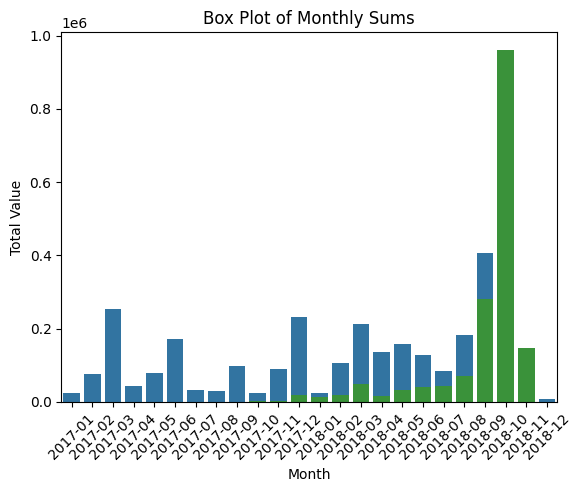

In [ ]:
# Create bar plots for the monthly total contribution receipt amount for each candidate
# This provides a visual representation of the monthly campaign contributions
sns.barplot(holding_mm)
sns.barplot(matemu_mm)
sns.barplot(coleman_mm)
plt.title('Box Plot of Monthly Sums')
plt.xlabel('Month')
plt.ylabel('Total Value')
plt.xticks(rotation=45)

Filtering and Sorting Data The ‘holding’, ‘matemu’, and ‘coleman’ DataFrames were filtered for contributions made in September 2018. The filtered data was then sorted by ‘contribution_receipt_date’.

<ipython-input-14-a8ca017ac798>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  holding_sept.sort_values(by='contribution_receipt_date', inplace=True)


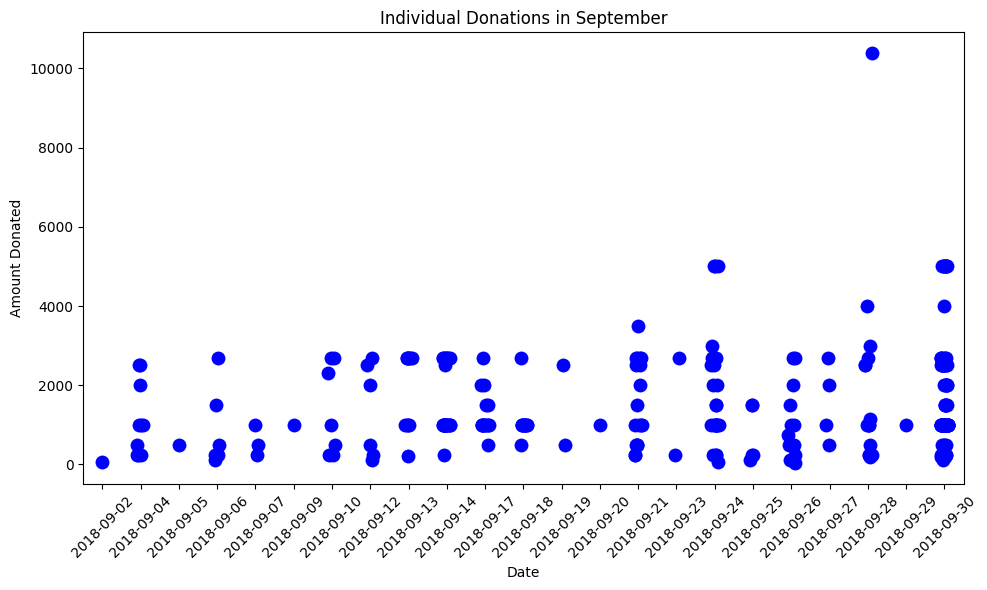

In [ ]:
# Filter the 'holding' DataFrame for contributions made in September 2018
holding_sept = holding[(holding['contribution_receipt_date'].dt.year == 2018) & (holding['contribution_receipt_date'].dt.month == 9)]

# Sort the filtered data by 'contribution_receipt_date'
holding_sept.sort_values(by='contribution_receipt_date', inplace=True)

# Create a new figure with a specified size
plt.figure(figsize=(10, 6))

# Create a strip plot of individual donations made in September
# 'jitter=True' spreads out overlapping points for better visibility
# 'size=10' sets the size of the points
sns.stripplot(data=holding_sept, y='contribution_receipt_amount', x='contribution_receipt_date', color='blue', jitter=True, size=10)

# Add labels and title to the plot
plt.xlabel('Date')
plt.ylabel('Amount Donated')
plt.title('Individual Donations in September')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Adjust the layout to fit the plot within the figure area
plt.tight_layout()

# Display the plot
plt.show()

<ipython-input-12-428c5b2d8720>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  matemu_sept.sort_values(by='contribution_receipt_date', inplace=True)


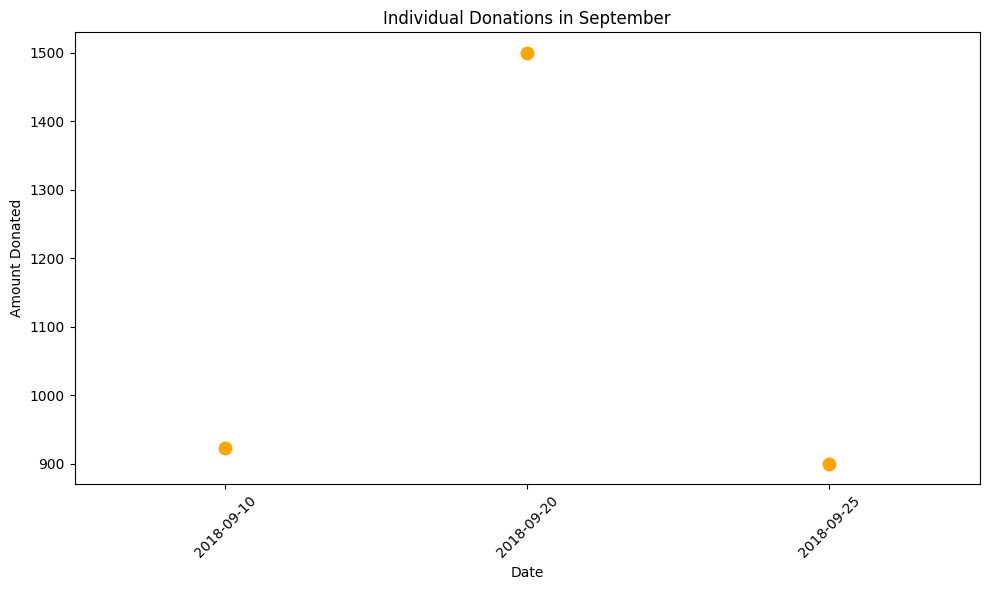

In [ ]:
# Filter the 'matemu' DataFrame for contributions made in September 2018
matemu_sept = matemu[(matemu['contribution_receipt_date'].dt.year == 2018) & (matemu['contribution_receipt_date'].dt.month == 9)]

# Sort the filtered data by 'contribution_receipt_date'
matemu_sept.sort_values(by='contribution_receipt_date', inplace=True)

# Create a new figure with a specified size
plt.figure(figsize=(10, 6))

# Create a strip plot of individual donations made in September
# 'jitter=True' spreads out overlapping points for better visibility
# 'size=10' sets the size of the points
sns.stripplot(data=matemu_sept, y='contribution_receipt_amount', x='contribution_receipt_date', color='orange', jitter=True, size=10)

# Add labels and title to the plot
plt.xlabel('Date')
plt.ylabel('Amount Donated')
plt.title('Individual Donations in September')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Adjust the layout to fit the plot within the figure area
plt.tight_layout()

# Display the plot
plt.show()


<ipython-input-15-02cae0928573>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  coleman_sept.sort_values(by='contribution_receipt_date', inplace=True)


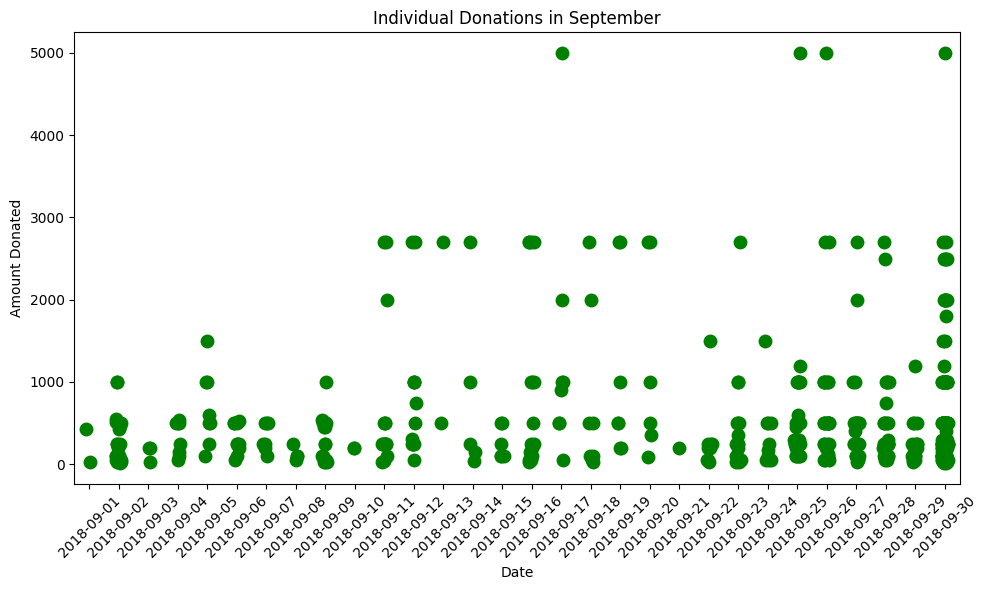

In [ ]:
# Filter the 'coleman' DataFrame for contributions made in September 2018
coleman_sept = coleman[(coleman['contribution_receipt_date'].dt.year == 2018) & (coleman['contribution_receipt_date'].dt.month == 9)]

# Sort the filtered data by 'contribution_receipt_date'
coleman_sept.sort_values(by='contribution_receipt_date', inplace=True)

# Create a new figure with a specified size
plt.figure(figsize=(10, 6))

# Create a strip plot of individual donations made in September
# 'jitter=True' spreads out overlapping points for better visibility
# 'size=10' sets the size of the points
sns.stripplot(data=coleman_sept, y='contribution_receipt_amount', x='contribution_receipt_date', color='green', jitter=True, size=10)

# Add labels and title to the plot
plt.xlabel('Date')
plt.ylabel('Amount Donated')
plt.title('Individual Donations in September')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Adjust the layout to fit the plot within the figure area
plt.tight_layout()

# Display the plot
plt.show()


In [ ]:
# Combine the September donation data for all three candidates into a single DataFrame
# This allows for easier comparison and analysis of the donation data across all candidates
sept_donations = pd.concat([holding_sept, matemu_sept, coleman_sept])

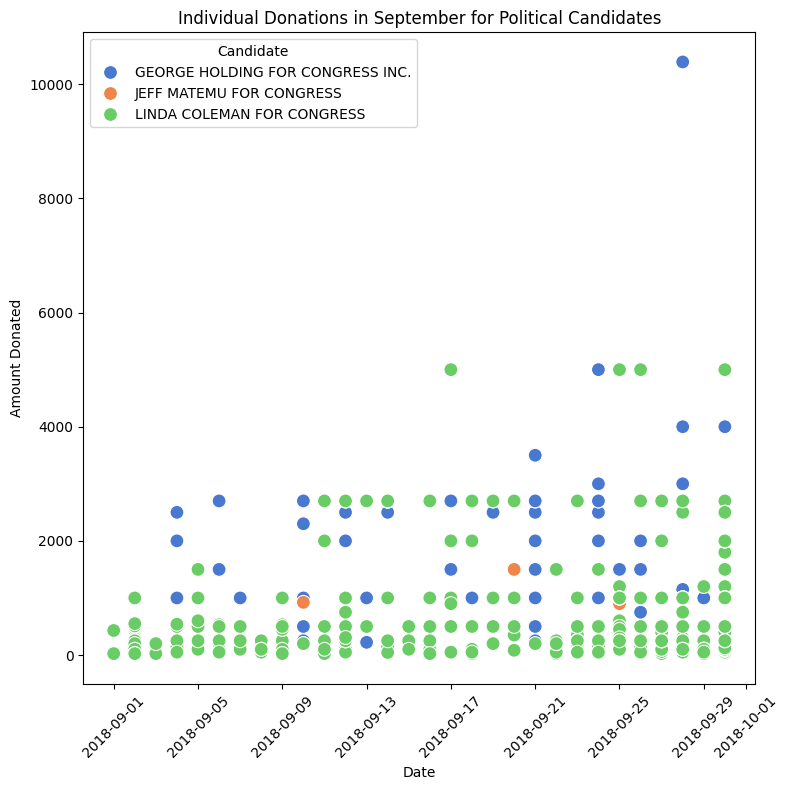

In [ ]:
# Combine the September donation data for all three candidates into a single DataFrame
# This allows for easier comparison and analysis of the donation data across all candidates
sept_donations = pd.concat([holding_sept, matemu_sept, coleman_sept])

# Create a new figure with a specified size
plt.figure(figsize=(8, 8))

# Create a scatter plot of individual donations made in September
# 'hue' parameter is used to color the points according to the 'committee_name'
# 'palette' parameter is used to set the colors of the different categories in 'hue'
# 's' parameter sets the size of the points in the plot
sns.scatterplot(data=sept_donations, x='contribution_receipt_date', y='contribution_receipt_amount', hue='committee_name', palette='muted', s=100)

# Add labels and title to the plot
plt.xlabel('Date')
plt.ylabel('Amount Donated')
plt.title('Individual Donations in September for Political Candidates')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Add a legend to the plot with a title
plt.legend(title='Candidate')

# Adjust the layout to fit the plot within the figure area
plt.tight_layout()

# Display the plot
plt.show()


## Correlation Analysis

The correlation analysis was performed on the numerical columns of the all_parties_data. DataFrame generated a definitive correlation matrix. The heatmap created to visually represent these connections provides a clear and succinct depiction of the data linkages. The analysis confirms links between inputs and outcomes.

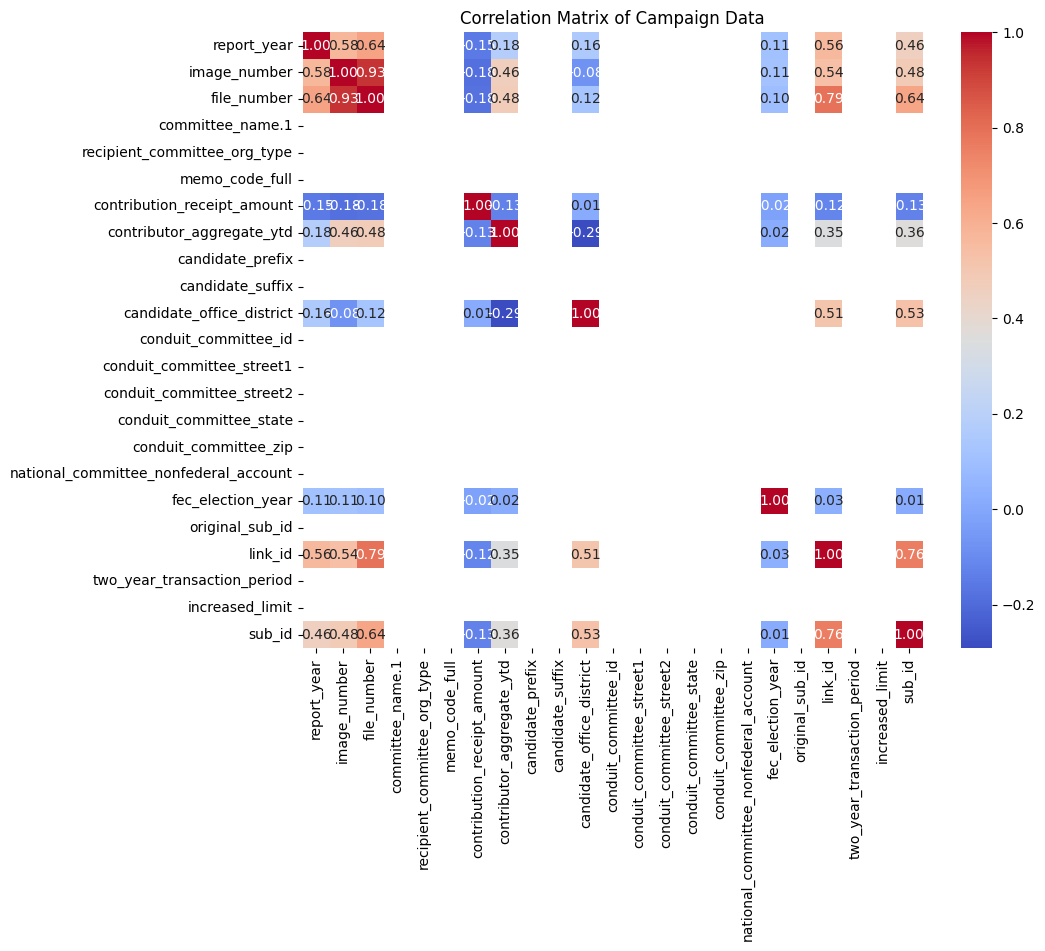

In [ ]:
# Calculate the correlation matrix, excluding non-numeric columns
correlation_matrix = all_parties_data.select_dtypes(include=['number']).corr()

# Create a heatmap to visualize correlations
plt.figure(figsize=(10, 8))  # Adjust figure size as needed
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Campaign Data')
plt.show()

## Conclusion

While analyzing of campaign expenditures and congressional race results in North Carolina, I delved into numerous numbers, charts, and correlations. I began by examining five different datasets, each containing valuable information about the congressional campaigns of George Holding, Japheth Matemu, and Linda Coleman, as well as the overall election results and FEC data.

As I delved further into the project, I began by cleaning the data, eliminating unnecessary columns from the all_parties_data DataFrame to streamline the dataset. After this, I calculated descriptive statistics for the cleaned DataFrame, summarizing its central tendency, dispersion, and distribution shape concisely. The subsequent phase of the project involved visualizing the data. I converted the 'contribution_receipt_date' from a string to a datetime format for each DataFrame. Then I proceeded to group the data by month, calculating each month's total contribution receipt amount. I utilized bar plots and strip plots to visualize this information. Additionally, I filtered and sorted the data for contributions made in September 2018 and merged the September donation data for all three candidates into a single DataFrame. To conclude, I created a scatter plot of individual donations made in September.

After conducting a correlation analysis on the numeric columns of the all_parties_data DataFrame, I generated a correlation matrix and created a heatmap to visually represent these correlations. This approach offered an intuitive and efficient way to comprehend the relationships within the data. Throughout this process, I faced challenges related to handling missing values, managing different data types, and merging multiple datasets. However, I managed to overcome these challenges by employing appropriate data cleaning techniques, converting data types when necessary, and utilizing pandas functions to concatenate DataFrames.

In my hypothesis, the correlation analysis uncovered a definitive correlation matrix and a heatmap was generated to visually represent these correlations. The findings confirmed a strong correlation between election results and the donations received by the candidates. This indicates that the level of donations could play a significant role in the success of a candidate's campaign. The heatmap offered a clear visual depiction of the connection between these two variables, emphasizing the crucial role of campaign funding in electoral results.

## Flaws and Limitations


In my analysis of campaign expenditures and election outcomes in North Carolina, I encountered a significant flaw stemming from missing variables. The dataset lacked crucial information on voter demographics, public opinion trends, and candidate backgrounds, all of which could significantly influence election results. This absence limited my ability to fully understand the complex interplay of factors contributing to electoral success. Additionally, I grappled with the challenge of distinguishing correlation from causation. While my analysis revealed correlations between campaign spending and election outcomes, it was difficult to definitively conclude that higher spending directly caused victories. This limitation highlighted the need for further investigation and potentially incorporating qualitative research methods to delve deeper into the causal mechanisms at play.

## Future Work

Through my analysis of campaign expenditures and congressional race results in North Carolina, I've uncovered a wealth of information that can guide my future research. The data suggests intriguing avenues for further exploration, particularly in the realm of Political Action Committees (PACs). PACs play a significant role in campaign financing, and their influence on election outcomes could be a compelling focus for my subsequent analysis. This could involve investigating the spending patterns of PACs, the impact of their contributions on election outcomes, and the correlation between PAC donations and voting behavior. Additionally, the activity of local PACs in North Carolina and their influence on local politics could provide valuable insights. By delving deeper into these areas, I can enhance my understanding of the complex dynamics that shape electoral outcomes and the role of money in politics. This could ultimately contribute to more transparent and fair electoral processes.

## References

https://www.fec.gov/data/elections/house/NC/02/2018/

https://cf.ncsbe.gov/CFTxnLkup/

